In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import rasterio

# PATHS
BASE_DIR = Path().resolve().parent

CONFIG = {
    "station_meta_csv": BASE_DIR / "Data/Stations/station_metadata_20241001_20250531.csv",
    "station_dir":      BASE_DIR / "Data/Stations",   # per-station CSVs
    "imerg_dir":        BASE_DIR / "Data/IMERG",      # parquet (wide)
    "mros_parquet":     BASE_DIR / "Data/observations/wy25_mros_obs.parquet",
    "dem_path":         BASE_DIR / "DEM_1km.tif",
    "out_dir":          BASE_DIR / "outputs/hourly_pipeline",
    "kriging_nc":       BASE_DIR / "outputs/hourly_pipeline/test5_hourly_predictors_1km_kriging.nc",
    "idw_nc":           Path("C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/full_window/hourly_predictors_1km.nc"), # too large to store on github so saved locally and in Google Drive data folder
}

VARS = ["mros_plp_proxy", "plp", "temp_air", "temp_wet", "temp_dew", "rh"]
XNAME, YNAME, TNAME = "x", "y", "time"

out_dir = Path(CONFIG["out_dir"])


In [2]:
# LOAD + ALIGN DATASETS
krig = xr.open_dataset(CONFIG["kriging_nc"])
idw  = xr.open_dataset(CONFIG["idw_nc"])
# print(krig["time"].values[:5])
# print(idw["time"].values[:5])

idw_sub = idw.sel({TNAME: krig[TNAME]})
krig = krig.sortby(TNAME)
idw_sub = idw_sub.sortby(TNAME)

# Align IDW with kriging test window
assert np.array_equal(krig[TNAME].values, idw_sub[TNAME].values)
print(idw_sub[TNAME].values[:20])


['2025-03-30T00:00:00.000000000' '2025-03-30T01:00:00.000000000'
 '2025-03-30T02:00:00.000000000' '2025-03-30T03:00:00.000000000'
 '2025-03-30T04:00:00.000000000' '2025-03-30T05:00:00.000000000'
 '2025-03-30T06:00:00.000000000' '2025-03-30T07:00:00.000000000'
 '2025-03-30T08:00:00.000000000' '2025-03-30T09:00:00.000000000'
 '2025-03-30T10:00:00.000000000' '2025-03-30T11:00:00.000000000'
 '2025-03-30T12:00:00.000000000' '2025-03-30T13:00:00.000000000'
 '2025-03-30T14:00:00.000000000' '2025-03-30T15:00:00.000000000'
 '2025-03-30T16:00:00.000000000' '2025-03-30T17:00:00.000000000'
 '2025-03-30T18:00:00.000000000' '2025-03-30T19:00:00.000000000']


In [ ]:
# Load hourly-level stations, IMERG, and MRoS:
st_hr   = pd.read_parquet(out_dir / "stations_hourly.parquet")
imerg_hr = pd.read_parquet(out_dir / "imerg_hourly.parquet")
mros_hr     = pd.read_parquet(out_dir / "mros_hourly.parquet")

# Open DEM
dem_path = "C:/Users/EmmaGolub/Desktop/MRoS_local/local_data/DEM_AOI_TNM_10m.tif"

def add_elev_from_dem(df, dem_path, lon_col="lon", lat_col="lat"):
    with rasterio.open(dem_path) as dem:
        coords = list(zip(df[lon_col], df[lat_col]))
        elev = np.array([val[0] for val in dem.sample(coords)])
    return df.assign(elev=elev)

mros_hr = add_elev_from_dem(mros_hr,   dem_path)
imerg_hr = add_elev_from_dem(imerg_hr, dem_path)


In [6]:
# Stations: wide → long
station_vars = ["temp_air", "temp_wet", "temp_dew", "rh"]

st_long = st_hr.melt(
    id_vars=["id", "hour_utc", "lat", "lon", "elev"],
    value_vars=station_vars,
    var_name="var",
    value_name="obs_value"
)
st_long["source"] = "stations"

# IMERG points: wide → long
imerg_long = imerg_hr.melt(
    id_vars=["hour_utc", "lat", "lon", "elev"],
    value_vars=["plp"],
    var_name="var",
    value_name="obs_value"
)
imerg_long["source"] = "imerg_points"

# MRoS proxies: wide → long
mros_long = mros_hr.melt(
    id_vars=["hour_utc", "lat", "lon", "elev"],
    value_vars=["mros_plp_proxy"],
    var_name="var",
    value_name="obs_value"
)
mros_long["source"] = "mros"

st_long = st_long.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
imerg_long = imerg_long.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})
mros_long  = mros_long.rename(columns={"hour_utc": "time", "lat": "y", "lon": "x"})

print(list(krig.data_vars))
print(st_long["var"].unique())
print(imerg_long["var"].unique())
print(mros_long["var"].unique())

print(st_long["time"].values[:5])
print(imerg_long["time"].values[:5])
print(mros_long["time"].values[:5])


['temp_air', 'temp_dew', 'temp_wet', 'rh', 'mros_plp_proxy', 'plp', 'elev', 'spatial_ref']
['temp_air' 'temp_wet' 'temp_dew' 'rh']
['plp']
['mros_plp_proxy']
['2024-10-01T08:00:00.000000000' '2024-10-01T09:00:00.000000000'
 '2024-10-01T10:00:00.000000000' '2024-10-01T11:00:00.000000000'
 '2024-10-01T12:00:00.000000000']
['2024-10-11T00:00:00.000000000' '2024-10-11T00:00:00.000000000'
 '2024-10-11T00:00:00.000000000' '2024-10-11T00:00:00.000000000'
 '2024-10-11T00:00:00.000000000']
['2024-10-06T21:00:00.000000000' '2024-10-06T21:00:00.000000000'
 '2024-10-06T23:00:00.000000000' '2024-10-07T01:00:00.000000000'
 '2024-10-07T02:00:00.000000000']


In [7]:
print("Krig dtype:", krig["time"].dtype)
print("IDW dtype:", idw_sub["time"].dtype)
print("Stations dtype:", st_long["time"].dtype)
print("IMERG dtype:", imerg_long["time"].dtype)
print("MRoS dtype:", mros_long["time"].dtype)

Krig dtype: datetime64[ns]
IDW dtype: datetime64[ns]
Stations dtype: datetime64[ns, UTC]
IMERG dtype: datetime64[ns, UTC]
MRoS dtype: datetime64[ns, UTC]


In [8]:
# Also align hourly datasets with testing window
for df in [st_long, imerg_long, mros_long]:
    df["time"] = pd.to_datetime(df["time"], utc=True) \
                   .dt.floor("h") \
                   .dt.tz_localize(None) # make tz naive
    
# Force to floats for all obs dataframes
for df in [st_long, imerg_long, mros_long]:
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")


krig_times = pd.to_datetime(krig["time"].values)

st_long = st_long[st_long["time"].isin(krig_times)]
imerg_long = imerg_long[imerg_long["time"].isin(krig_times)]
mros_long  = mros_long[mros_long["time"].isin(krig_times)]

print(st_long.dtypes)
print(imerg_long.dtypes)
print(mros_long.dtypes)


id                   object
time         datetime64[ns]
y                   float64
x                   float64
elev                float64
var                  object
obs_value           float64
source               object
dtype: object
time         datetime64[ns]
y                   float64
x                   float64
elev                float32
var                  object
obs_value           float64
source               object
dtype: object
time         datetime64[ns]
y                   float64
x                   float64
elev                float32
var                  object
obs_value           float64
source               object
dtype: object


In [9]:
# VALIDATION + METRICS
def compute_metrics(err: np.ndarray) -> dict:
    return {
        "rmse": float(np.sqrt(np.nanmean(err**2))),
        "mae":  float(np.nanmean(np.abs(err))),
        "bias": float(np.nanmean(err)),
        "n":    int(np.sum(~np.isnan(err))),
    }

# Iterate over unique times in small batches to save memory
def sample_ds_at_points(ds: xr.Dataset, points_long: pd.DataFrame, var: str,
                        xname=XNAME, yname=YNAME, tname=TNAME) -> np.ndarray:
    sub = points_long.loc[points_long["var"] == var].copy()
    if sub.empty:
        return np.array([])
    
    results = []
    for t, sub_t in sub.groupby("time"):
        try:
            # select single time slice and reduce to 2D array, then interpolate slice at obs locations for that time
            f_time = ds[var].sel({tname: t}, method="nearest")
        except Exception:
            continue
        sampled = f_time.interp(
            {xname: xr.DataArray(sub_t[xname].values, dims="obs"),
             yname: xr.DataArray(sub_t[yname].values, dims="obs")}
        )
        results.append(pd.Series(sampled.values, index=sub_t.index))
    
    if results:
        return pd.concat(results).sort_index().values
    else:
        return np.array([])


# loop over each var and sample predictions from both kriging and IDW datasets at obs coordinates and times, then compare to observed values
def evaluate_source(points_long: pd.DataFrame, source_name: str, return_residuals=False) -> pd.DataFrame:
    rows = []
    resid_rows = []

    for var in sorted(set(points_long["var"]) & set(VARS)):
        pred_k = sample_ds_at_points(krig,   points_long, var)
        pred_i = sample_ds_at_points(idw_sub, points_long, var)
        sub = points_long.loc[points_long["var"] == var].copy()
        obs = sub["obs_value"].to_numpy(dtype=float)
        m = min(len(obs), len(pred_k), len(pred_i))
        obs, pred_k, pred_i = obs[:m], pred_k[:m], pred_i[:m]
        err_k, err_i = pred_k - obs, pred_i - obs

        rows += [
            {"source": source_name, "var": var, "method": "kriging", **compute_metrics(err_k)},
            {"source": source_name, "var": var, "method": "idw",     **compute_metrics(err_i)},
        ]
        
        if return_residuals:
            resid_rows.append(
                pd.DataFrame({
                    "source": source_name,
                    "var": var,
                    "time": sub["time"].values[:m],
                    "x": sub["x"].values[:m],
                    "y": sub["y"].values[:m],
                    "elev": sub["elev"].values[:m] if "elev" in sub.columns else np.full(m, np.nan),
                    "obs": obs,
                    "pred_krig": pred_k,
                    "pred_idw": pred_i,
                    "resid_krig": err_k,
                    "resid_idw": err_i,
                })
            )

    metrics = pd.DataFrame(rows)
    if return_residuals:
        return metrics, pd.concat(resid_rows, ignore_index=True)
    else:
        return metrics

In [10]:
# Run for each source, capturing metrics + residuals
metrics_stn,  resid_stn  = evaluate_source(st_long,   "stations", return_residuals=True)
metrics_mros, resid_mros = evaluate_source(mros_long, "mros", return_residuals=True)
metrics_imrg, resid_imrg = evaluate_source(imerg_long,"imerg_points", return_residuals=True)

# Combine all summary metrics
all_metrics = pd.concat([metrics_stn, metrics_mros, metrics_imrg], ignore_index=True)

# Combine all row-level residuals
all_residuals = pd.concat([resid_stn, resid_mros, resid_imrg], ignore_index=True)


In [11]:
# Plotting
# reshape residuals
def _to_long_residuals(resid_df):
    """Convert wide resid_krig / resid_idw into long format with 'method' + 'residual'."""
    df = resid_df.melt(
        id_vars=["source", "var", "time", "x", "y", "elev", "obs"],
        value_vars=["resid_krig", "resid_idw"],
        var_name="method", value_name="residual"
    )
    return df.replace({"resid_krig": "kriging", "resid_idw": "idw"})


PALETTE = {"kriging": "C0", "idw": "C1"}  # consistent colors

# RMSE barplot
def plot_rmse_bar(metrics_df, outdir=None, logscale=False, rmse_clip=500):
    df = metrics_df.copy()
    # Clip extreme RMSE values
    df.loc[df["rmse"] > rmse_clip, "rmse"] = np.nan

    g = sns.catplot(
        data=df,
        x="var", y="rmse", hue="method", col="source",
        kind="bar", errorbar=None, height=4, aspect=1.2,
        palette=PALETTE
    )
    if logscale:
        g.set(yscale="log")
    g.set_axis_labels("Variable", "RMSE")
    g.set_titles("{col_name}")
    plt.tight_layout()
    if outdir:
        g.savefig(Path(outdir) / "rmse_by_variable_source.png", dpi=200)
    plt.show()

# Residuals vs Elevation
def plot_resid_vs_elev(resid_df, outdir=None):
    if "elev" not in resid_df.columns:
        print("No elevation column in data.")
        return

    df = _to_long_residuals(resid_df).dropna(subset=["elev"])

    g = sns.FacetGrid(df, col="var", col_wrap=3, height=4, sharey=False)
    g.map_dataframe(
        sns.scatterplot,
        x="elev", y="residual", hue="method",
        alpha=0.4, s=15, palette=PALETTE
    )
    g.map_dataframe(
        sns.lineplot,
        x="elev", y="residual", hue="method",
        estimator="mean", lw=2, palette=PALETTE, legend=False
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="k", ls="--")
    g.set_axis_labels("Elevation (m)", "Residual (pred - obs)")
    g.add_legend(title="Method")
    plt.tight_layout()
    if outdir:
        g.savefig(Path(outdir) / "residuals_vs_elevation_by_var.png", dpi=200)
    plt.show()


# Residuals by Elevation Band
def plot_resid_box_by_band(resid_df, outdir=None, bins=(0,1500,2500,4000)):
    if "elev" not in resid_df.columns:
        print("No elevation column in data.")
        return

    df = _to_long_residuals(resid_df).dropna(subset=["elev"])
    df["elev_band"] = pd.cut(df["elev"], bins=bins, include_lowest=True)
    df["elev_band"] = df["elev_band"].astype(str)

    g = sns.catplot(
        data=df,
        x="elev_band", y="residual", hue="method", col="var",
        kind="box", col_wrap=3, height=4, sharey=False,
        palette=PALETTE
    )
    for ax in g.axes.flatten():
        ax.axhline(0, color="k", ls="--")
    g.set_axis_labels("Elevation band (m)", "Residual (pred - obs)")
    g.set_titles("{col_name}")
    g.add_legend(title="Method")
    plt.tight_layout()
    if outdir:
        g.savefig(Path(outdir) / "residuals_by_band_by_var.png", dpi=200)
    plt.show()

Plotting RMSE barplot...


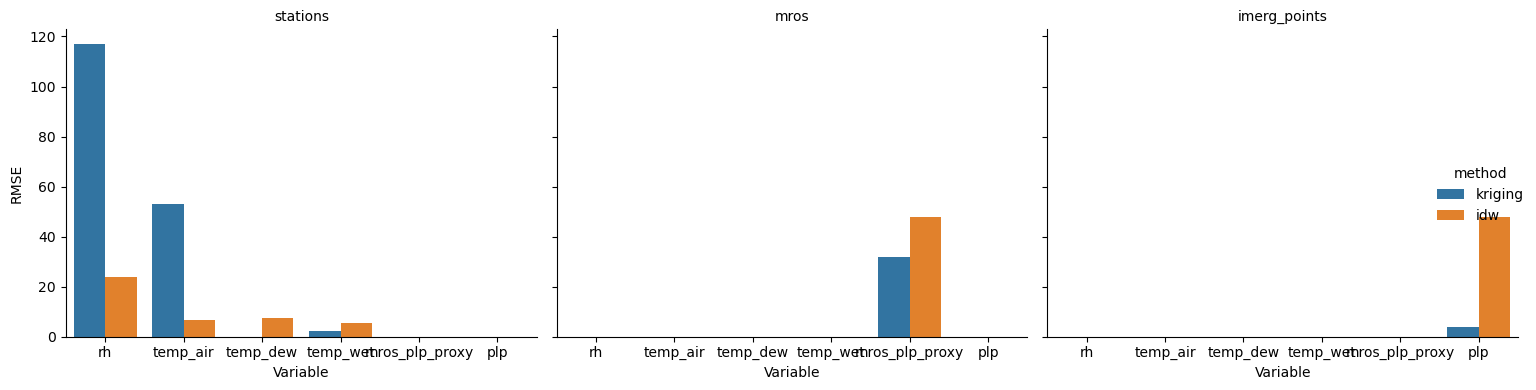

Plotting residuals vs elevation...


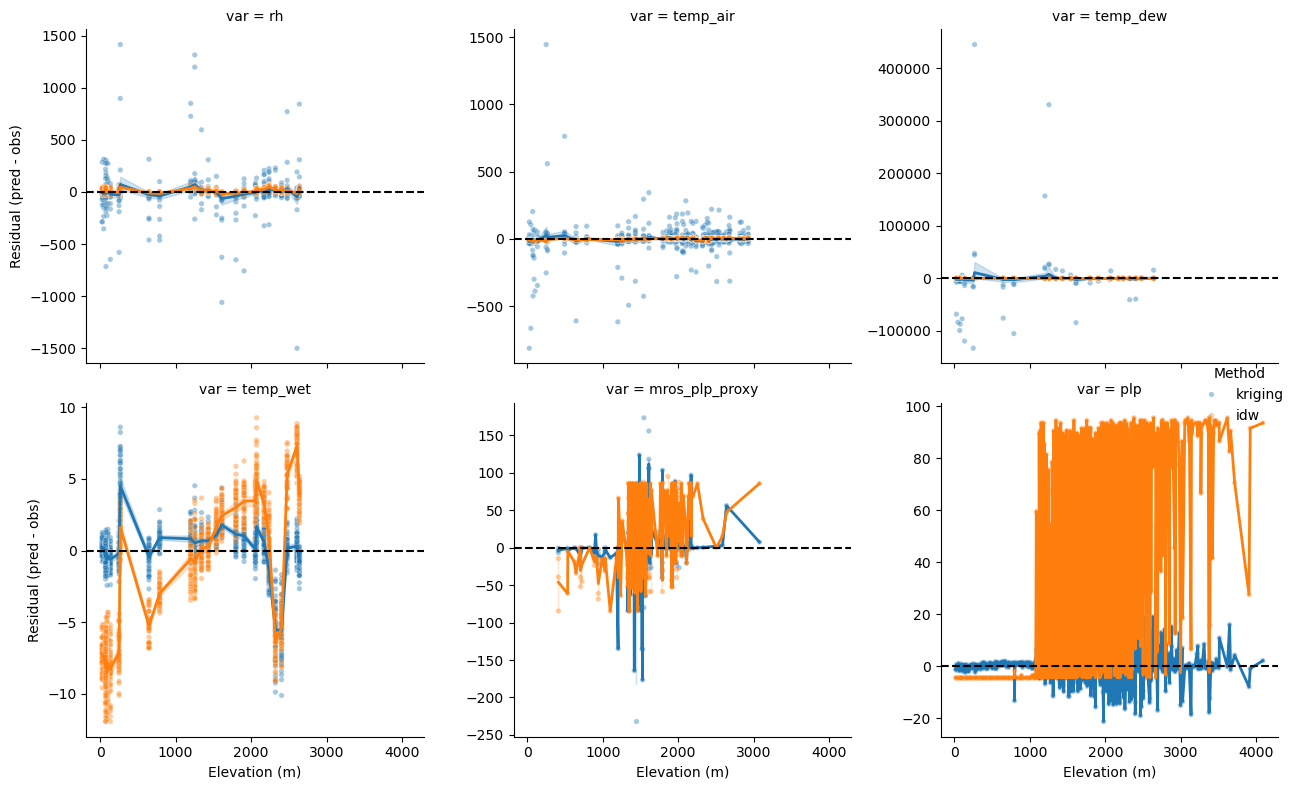

Plotting residuals by elevation band...


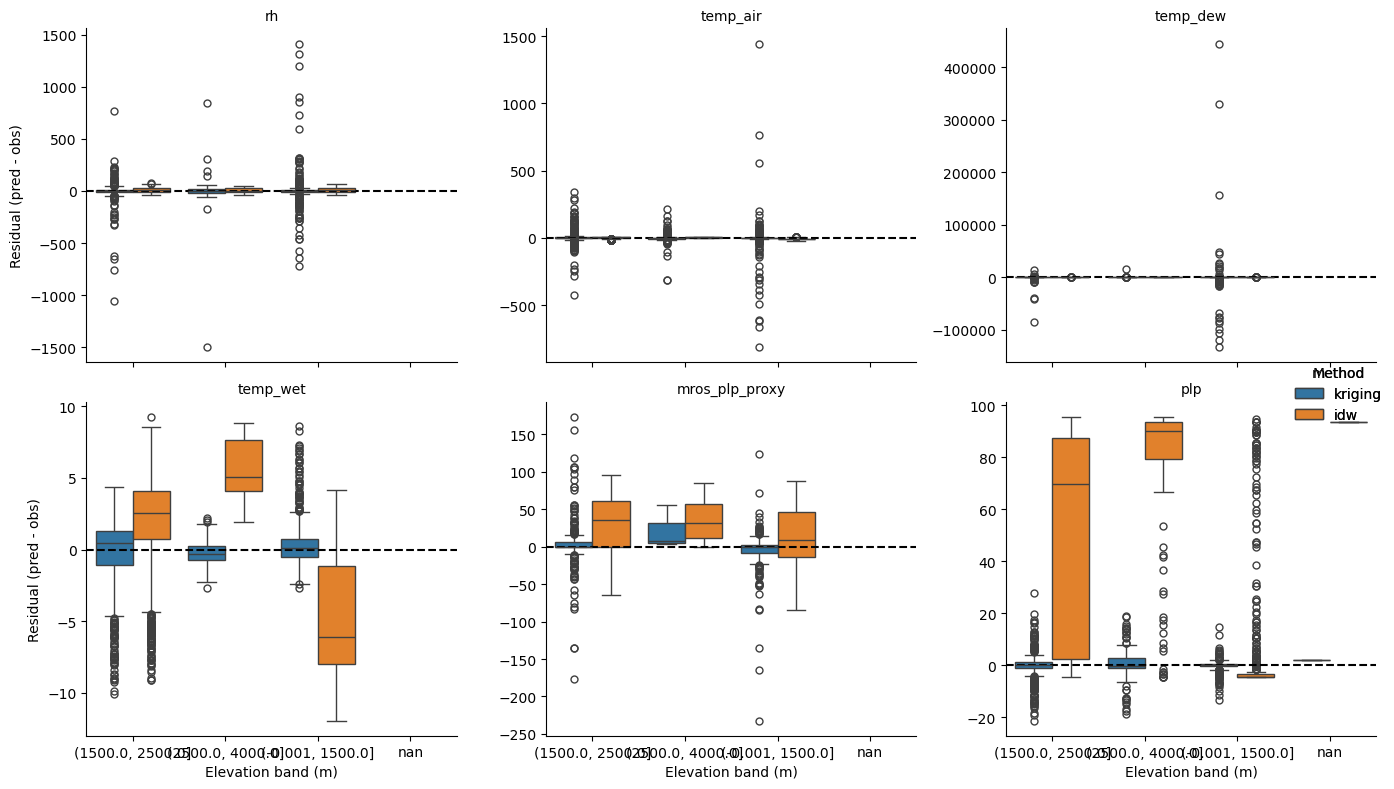

In [12]:
print("Plotting RMSE barplot...")
plot_rmse_bar(all_metrics, outdir=out_dir, logscale=False)

print("Plotting residuals vs elevation...")
plot_resid_vs_elev(all_residuals, outdir=out_dir)

print("Plotting residuals by elevation band...")
plot_resid_box_by_band(all_residuals, outdir=out_dir, bins=(0,1500,2500,4000))